ROUGE scores for Summarization: {'rouge-1': {'r': 1.0, 'p': 0.7333333333333333, 'f': 0.8461538412721893}, 'rouge-2': {'r': 0.9946808510638298, 'p': 0.677536231884058, 'f': 0.8060344779384662}, 'rouge-l': {'r': 1.0, 'p': 0.7333333333333333, 'f': 0.8461538412721893}}
Query query_1 - Exact Match (EM): 0
Query query_1 - Precision: 0.23404255319148937, Recall: 0.7857142857142857, F1: 0.36065573770491804
ROUGE scores for query_1: {'rouge-1': {'r': 0.7857142857142857, 'p': 0.23404255319148937, 'f': 0.3606557341682344}, 'rouge-2': {'r': 0.7692307692307693, 'p': 0.15625, 'f': 0.25974025693371566}, 'rouge-l': {'r': 0.7857142857142857, 'p': 0.23404255319148937, 'f': 0.3606557341682344}}
Query query_2 - Exact Match (EM): 0
Query query_2 - Precision: 0.22388059701492538, Recall: 0.75, F1: 0.3448275862068966
ROUGE scores for query_2: {'rouge-1': {'r': 0.75, 'p': 0.22388059701492538, 'f': 0.3448275826661382}, 'rouge-2': {'r': 0.6666666666666666, 'p': 0.15730337078651685, 'f': 0.25454545145619834}, 'r

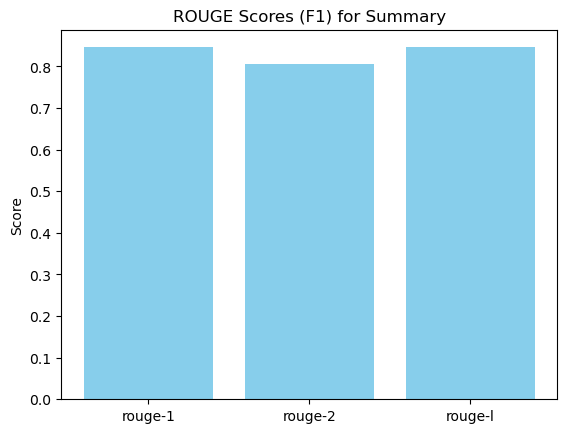

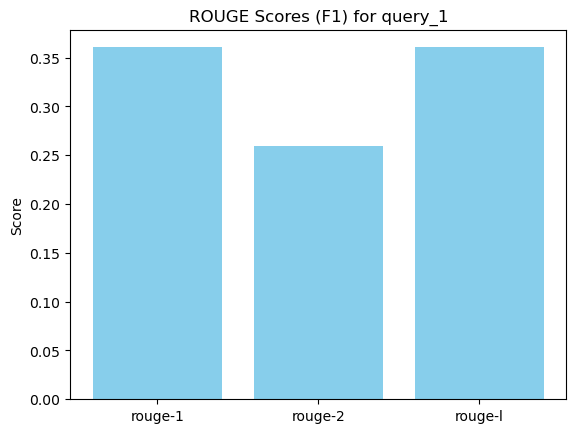

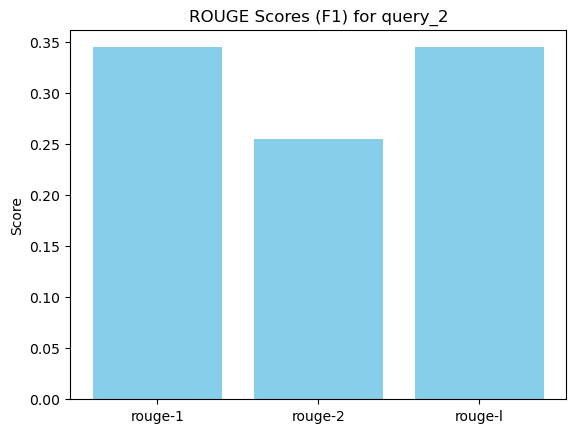

In [25]:
import json
from rouge import Rouge
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt

# Tokenize answers for F1 score calculation
def f1_score_token_level(true_answer, predicted_answer):
    true_tokens = set(true_answer.split())
    predicted_tokens = set(predicted_answer.split())

    common_tokens = true_tokens.intersection(predicted_tokens)

    if len(common_tokens) == 0:
        return 0.0, 0.0, 0.0  # Precision, Recall, F1

    precision = len(common_tokens) / len(predicted_tokens)
    recall = len(common_tokens) / len(true_tokens)

    if precision + recall == 0:
        f1 = 0
    else:
        f1 = 2 * (precision * recall) / (precision + recall)

    return precision, recall, f1

# Step 1: Precompute and Store Summaries and QA Responses
precomputed_results = {
    "summary": {
        "doc_name": "ArmstrongFlooringInc_20190107_8-K",
        "generated_summary": """
        Logo Usage: The logo must be used as a whole and cannot be modified in any way, including font, spacing, boldness, or color.
        Logo Background: The logo should never be used on a busy background or one that does not provide enough contrast.
        Clear Space: The size of the clear space around the logo is determined by the size of the circle of the capital height of the word "Diamond."
        Font: The Diamond 10 Technology logo is considered art and the font type, spacing, bold, cannot be modified.
        Logo Direction: The logo can be used on an angle or vertically but must read left to right and top to bottom.
        Circle A: The Circle A can never be used as a separate graphic element.
        Trademark Notice: The trademark should always be distinguishable from surrounding text, and the TM or ® symbol must be included in the first instance of the trademark.
        Product Crediting: When using Diamond 10 Technology in sentences to identify goods or services, include notice of AFI Licensing LLC's ownership of the trademark within the credit notice of the product, product documentation, or other product communication.
        Logo Colors: The logo can appear only in White or 4-Color Process comprised of Morado, Tungsten, and Black. If reversed out White, use only on dark background color for contrast.
        Logo Size: A general guideline for the maximum width of the logo in any application should be the equivalent to 20% of the width of the shortest side. Exceptions may be made for signage and promotional materials. The minimum logo size is 1” or 25mm. In digital formats, the minimum width is 100 pixels at 72 dpi.
        It is important to note that these guidelines are subject to change, and it is recommended to consult with Armstrong Flooring, Inc. for any updates or clarifications regarding the usage of their logos.
        """
    },
    "qa": {
        "query_1": {
            "reference_answer": """
            Logo Size: The minimum order size for the Diamond 10 Technology trademark is $500,000.
            """,
            "generated_answer": """
            Yes, there is a minimum order size or minimum amount per time period that one party must buy from the counterparty under the contract. According to Exhibit 10.2 of the Intellectual Property Agreement, the minimum order size for the Diamond 10 Technology trademark is $500,000. This means that if a party wants to use the Diamond 10 Technology trademark, they must place an order with a minimum value of $500,000.
            """
        },
        "query_2": {
            "reference_answer": """
            Yes, there is a requirement not to disparage the counterparty in the Intellectual Property Agreement with the Seller Licensed Trademarks or Arizona.
            """,
            "generated_answer": """
            Yes, there is a requirement not to disparage the counterparty in the Intellectual Property Agreement attached to Armstrong Flooring Inc.'s 8-K filing on January 7, 2019. Specifically, Section 3.4 of the agreement states: "Counterparty shall not, and shall cause its Affiliates and sublicensees not to, disparage or make any negative statements about Licensor or its products." This suggests that Armstrong Flooring Inc. has a right to protect its reputation and intellectual property, and any unauthorized criticism or negative statements about the company or its products could be considered a violation of this agreement.
            """
        }
    }
}

# Step 2: Evaluation on Precomputed Results

# ROUGE evaluation for summarization
reference_summary = """
The logo must be used as a whole and cannot be modified in any way, including font, spacing, boldness, or color.
Logo Background: The logo should never be used on a busy background or one that does not provide enough contrast.
Product Crediting: When using Diamond 10 Technology in sentences to identify goods or services, include notice of AFI Licensing LLC's ownership of the trademark within the credit notice of the product, product documentation, or other product communication.
Logo Colors: The logo can appear only in White or 4-Color Process comprised of Morado, Tungsten, and Black. If reversed out White, use only on dark background color for contrast.
Logo Size: A general guideline for the maximum width of the logo in any application should be the equivalent to 20% of the width of the shortest side. Exceptions may be made for signage and promotional materials. The minimum logo size is 1” or 25mm. In digital formats, the minimum width is 100 pixels at 72 dpi.
It is important to note that these guidelines are subject to change, and it is recommended to consult with Armstrong Flooring, Inc. for any updates or clarifications regarding the usage of their logos.
"""

generated_summary = precomputed_results["summary"]["generated_summary"]

rouge = Rouge()
rouge_scores_summary = rouge.get_scores(generated_summary, reference_summary, avg=True)
print(f"ROUGE scores for Summarization: {rouge_scores_summary}")

# Step 3: Apply ROUGE on QA Queries

rouge_scores_qa = {}  # Store ROUGE scores for each QA query
for query_id, qa_pair in precomputed_results["qa"].items():
    true_answer = qa_pair["reference_answer"].strip()
    predicted_answer = qa_pair["generated_answer"].strip()

    # Compute ROUGE scores for QA queries
    rouge_scores_qa[query_id] = rouge.get_scores(predicted_answer, true_answer, avg=True)

    # Exact Match (EM)
    exact_match = int(true_answer == predicted_answer)
    print(f"Query {query_id} - Exact Match (EM): {exact_match}")

    # F1 score at token level
    precision, recall, f1 = f1_score_token_level(true_answer, predicted_answer)
    print(f"Query {query_id} - Precision: {precision}, Recall: {recall}, F1: {f1}")
    print(f"ROUGE scores for {query_id}: {rouge_scores_qa[query_id]}")

# Step 4: Visualization of Metrics

# Function to plot ROUGE scores
def plot_rouge_scores(rouge_scores, title="ROUGE Scores"):
    keys = ['rouge-1', 'rouge-2', 'rouge-l']
    scores = [rouge_scores[k]['f'] for k in keys]
    plt.bar(keys, scores, color='skyblue')
    plt.title(title)
    plt.ylabel("Score")
    plt.show()

# Function to plot QA metrics
def plot_qa_metrics(qa_metrics):
    metrics_names = ['Precision', 'Recall', 'F1', 'Exact Match']
    
    # Split metrics into separate lists for plotting
    precision_scores = [metrics[0] for metrics in qa_metrics]
    recall_scores = [metrics[1] for metrics in qa_metrics]
    f1_scores = [metrics[2] for metrics in qa_metrics]
    exact_match_scores = [metrics[3] for metrics in qa_metrics]
    
    fig, ax = plt.subplots(2, 1, figsize=(8, 6))

    # Plot Precision, Recall, F1
    ax[0].bar(metrics_names[:3], [sum(precision_scores) / len(precision_scores), 
                                  sum(recall_scores) / len(recall_scores), 
                                  sum(f1_scores) / len(f1_scores)], color='lightgreen')
    ax[0].set_title("Average QA Precision, Recall, and F1 Score")
    ax[0].set_ylabel("Score")
    
    # Plot Exact Match
    ax[1].bar(metrics_names[3], sum(exact_match_scores) / len(exact_match_scores), color='coral')
    ax[1].set_title("Exact Match Score for QA")
    ax[1].set_ylabel("Score")
    
    plt.tight_layout()
    plt.show()

# Plotting the metrics
plot_rouge_scores(rouge_scores_summary, title="ROUGE Scores (F1) for Summary")

# Plot ROUGE scores for each QA query
for query_id, scores in rouge_scores_qa.items():
    plot_rouge_scores(scores, title=f"ROUGE Scores (F1) for {query_id}")

